<a href="https://colab.research.google.com/github/jbuiless/Pruebas/blob/main/Gestion_costos_operativos_Proyecto_construccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gestión de Costos Operativos en un Proyecto de Construcción

**Autor:** Juliana Builes Sepúlveda | **Análisis:** Prueba técnica Dataknow

**Versión:** 1.0 | **Estado:** Activo | **Última Actualización:** 2026-08-10


**Contexto:**  
Una empresa del sector constructor se encuentra en la fase de planificación de un
proyecto con una ventana de ejecución definida. Durante este período, la empresa deberá
gestionar el suministro continuo de dos tipos de equipos críticos para las operaciones en
campo. Históricamente, el costo de adquisición de estos equipos ha mostrado
comportamientos variables que la empresa no ha logrado anticipar con precisión, lo que
ha generado desviaciones presupuestales recurrentes.

## Tabla de Contenido
1. [Objetivo de Negocio](#1-objetivo-de-negocio)
2. [Configuración y librerías](#2-configuracion)
3. [Diccionario de datos](#3-diccionario)
4. [Carga y validación de datos](#4-carga)
5. [Exploración univariada](#5-eda)
6. [Análisis de correlación](#6-correlacion)
7. [Cointegración: ADF y Engle-Granger](#7-cointegracion)
8. [Diagnóstico de quiebre estructural](#8-quiebre)
9. [Cointegración multivariada y VECM](#9-vecm)
10. [Validación del pronóstico (walk-forward)](#10-validacion)
11. [Simulación Monte Carlo](#11-montecarlo)
12. [Conclusiones de negocio y limitaciones](#12-conclusiones)

---

## 1. Objetivo de Negocio del Proyecto

Proyectar el comportamiento esperado del costo de los equipos críticos hacia el futuro,
con una cuantificación explícita de la incertidumbre, para reducir las desviaciones
presupuestales del proyecto de construcción.

---
## 1.1. Objetivos específicos

1.1.1. Contar con un mecanismo reproducible para anticipar costos de equipos antes del
inicio de cada fase del proyecto.

1.1.2. Reducir las desviaciones presupuestales asociadas a la volatilidad en los precios de
insumos.

1.1.3. Establecer una base analítica que permita evaluar y comparar proveedores de
forma objetiva.

## 1. Configuración y librerias

Establece rutas y carga las librerías necesarias para todo el notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, coint, zivot_andrews
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Ejecutar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuración de ruta
DATA_DIR = "/content/drive/MyDrive/Datos_colab/"

print(f"pandas version: {pd.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pandas version: 2.2.2


## 3. Diccionario de datos <a id='3-diccionario'></a>

| Archivo | Columnas | Descripción | Formato particular |
|---|---|---|---|
| `historico_equipos.csv` | Date, Price_X, Price_Y, Price_Z, Price_Equipo1, Price_Equipo2 | Serie histórica consolidada 2010-2023 | Estándar |
| `X.csv` | Date, Price | Precio diario, insumo X| Estándar |
| `Y.csv` | Date, Price | Precio diario, insumo Y| `;` como separador,  decimal con coma |
| `Z.csv` | Price, Date | Precio diario, insumo Z | Orden de columnas invertido |
| `Price_Equipo1` | — | Índice de costo del equipo 1| — |
| `Price_Equipo2` | — | Índice de costo del equipo 2 | — |


## 4. Carga y validación de datos <a id='4-carga'></a>

In [2]:
# historico_equipos.csv
historico_equipos = pd.read_csv(f"{DATA_DIR}historico_equipos.csv", parse_dates=['Date'])

# X.csv
X = pd.read_csv(f"{DATA_DIR}X.csv", parse_dates=['Date'])

# Y.csv: separador ';',decimal con coma
Y = pd.read_csv(f"{DATA_DIR}Y.csv", sep=';', encoding='utf-8-sig')
Y['Price'] = Y['Price'].astype(str).str.replace(',', '.').astype(float)
Y['Date'] = pd.to_datetime(Y['Date'], dayfirst=True)

# Z.csv
Z = pd.read_csv(f"{DATA_DIR}Z.csv", parse_dates=['Date'])

In [3]:
# Validación carga de archivos
for name, df in [('historico', historico_equipos), ('X', X), ('Y', Y), ('Z', Z)]:
    print(f"{name}: {df.shape[0]} filas, {df.shape[1]} columnas, "
          f"nulos={df.isnull().sum().sum()}, fechas duplicadas={df['Date'].duplicated().sum()}")
    print(f"{name}: {df['Date'].min().date()} | {df['Date'].max().date()}  ({len(df)} filas)")
    print(df.dtypes.to_dict())
    print(df.head(2))
    print()

historico: 3530 filas, 6 columnas, nulos=0, fechas duplicadas=0
historico: 2010-01-04 | 2023-08-31  (3530 filas)
{'Date': dtype('<M8[ns]'), 'Price_X': dtype('float64'), 'Price_Y': dtype('float64'), 'Price_Z': dtype('float64'), 'Price_Equipo1': dtype('float64'), 'Price_Equipo2': dtype('float64')}
        Date  Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
0 2010-01-04    80.12    527.5  2225.25         434.73         931.73
1 2010-01-05    80.59    527.5  2246.50         449.97         968.56

X: 9144 filas, 2 columnas, nulos=0, fechas duplicadas=0
X: 1988-06-27 | 2024-04-04  (9144 filas)
{'Date': dtype('<M8[ns]'), 'Price': dtype('float64')}
        Date  Price
0 2024-04-04  89.18
1 2024-04-03  89.35

Y: 4485 filas, 2 columnas, nulos=0, fechas duplicadas=0
Y: 2006-07-11 | 2023-09-12  (4485 filas)
{'Date': dtype('<M8[ns]'), 'Price': dtype('float64')}
        Date   Price
0 2023-09-12  547.33
1 2023-09-11  546.00

Z: 3565 filas, 2 columnas, nulos=0, fechas duplicadas=0
Z: 2010-0

## 5. Exploracion univariada <a id='5-eda'></a>

Estadísticas descriptivas, outliers y visualización de cada serie


 Price_X (histórico) 
min=19.33  max=127.98  media=78.09  mediana=75.40  std=25.19  CV=32.25%

 Price_Y (histórico) 
min=257.50  max=1062.37  media=555.53  mediana=541.62  std=138.49  CV=24.93%

 Price_Z (histórico) 
min=1421.50  max=3984.00  media=2037.43  mediana=1974.75  std=373.14  CV=18.31%

 Price_Equipo1 
min=208.34  max=855.32  media=460.04  mediana=451.25  std=113.68  CV=24.71%

 Price_Equipo2 
min=566.00  max=1703.96  media=889.98  mediana=869.78  std=170.04  CV=19.11%

 Valores atípicos (>3 desviaciones estándar) 
Price_X (histórico): 0 outliers
Price_Y (histórico): 8 outliers
Price_Z (histórico): 56 outliers
Price_Equipo1: 7 outliers
Price_Equipo2: 45 outliers


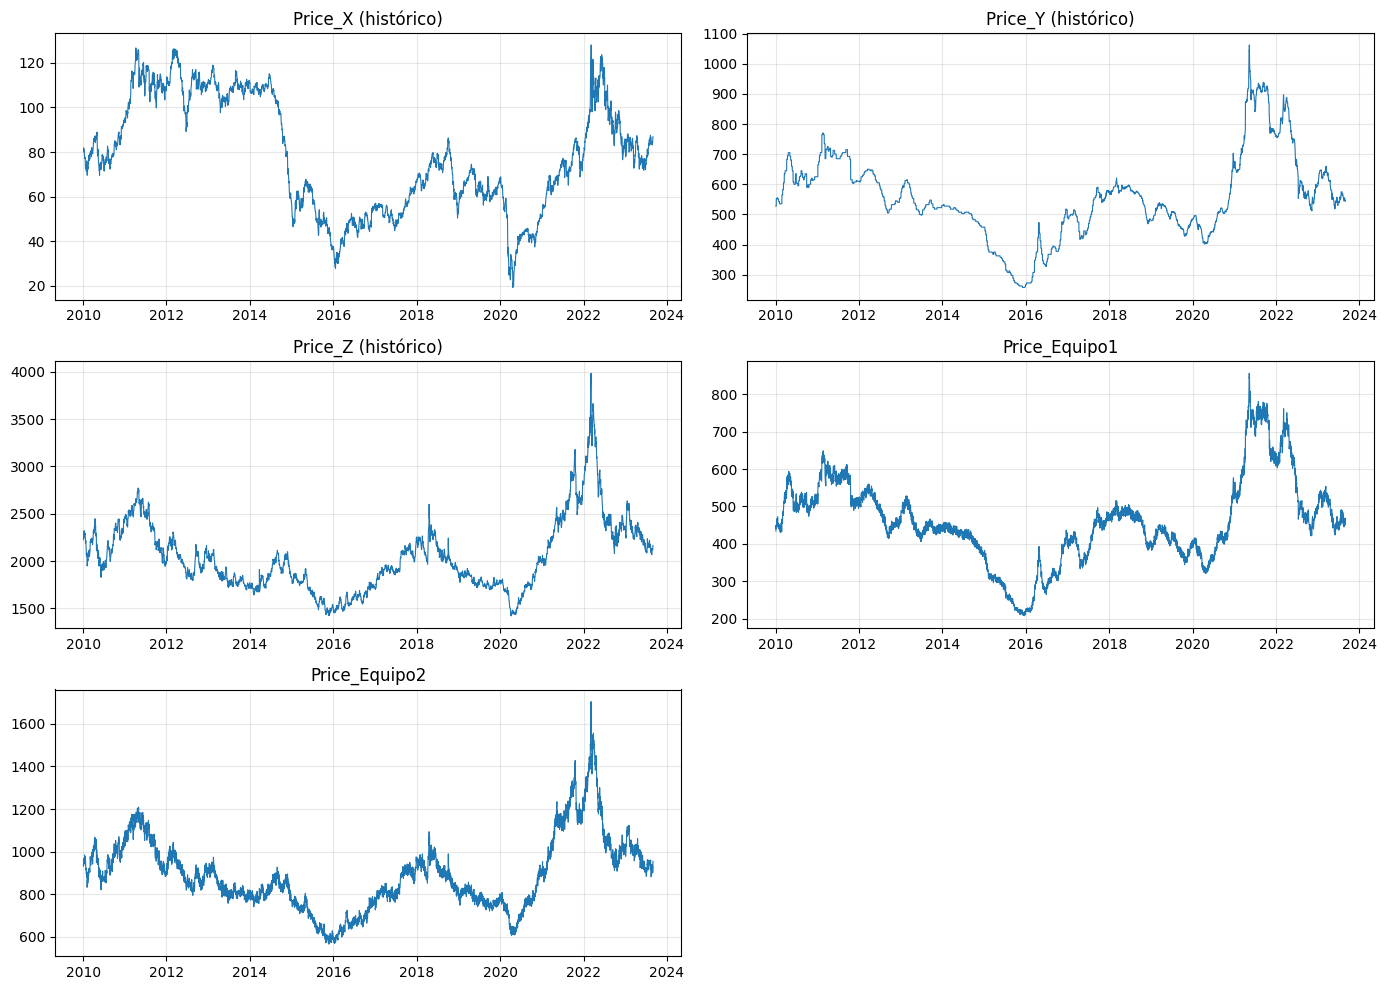

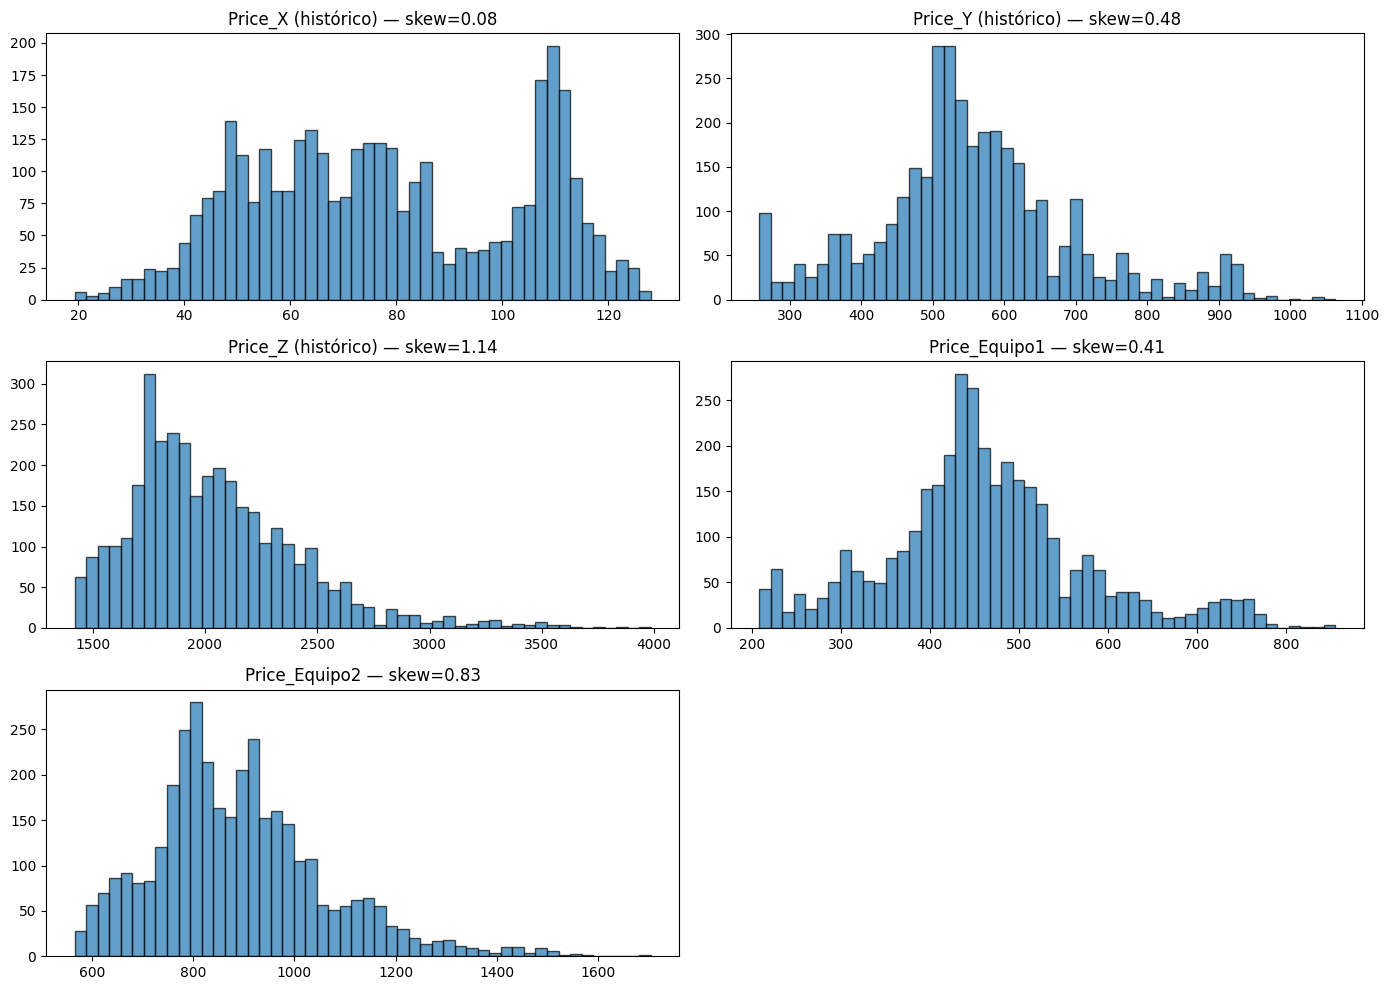

In [11]:
import matplotlib.pyplot as plt

# Estadísticas descriptivas
series_historico = {
    'Price_X (histórico)': historico_equipos['Price_X'],
    'Price_Y (histórico)': historico_equipos['Price_Y'],
    'Price_Z (histórico)': historico_equipos['Price_Z'],
    'Price_Equipo1': historico_equipos['Price_Equipo1'],
    'Price_Equipo2': historico_equipos['Price_Equipo2'],
}

for name, serie in series_historico.items():
    print(f"\n {name} ")
    print(f"min={serie.min():.2f}  max={serie.max():.2f}  media={serie.mean():.2f}  "
          f"mediana={serie.median():.2f}  std={serie.std():.2f}  CV={serie.std()/serie.mean():.2%}")

# Detección de outliers (z-score > 3)
print("\n Valores atípicos (>3 desviaciones estándar) ")
for name, serie in series_historico.items():
    z = (serie - serie.mean()) / serie.std()
    n_outliers = (z.abs() > 3).sum()
    print(f"{name}: {n_outliers} outliers")

# Visualización de cada serie en el tiempo
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, serie) in enumerate(series_historico.items()):
    axes[i].plot(historico_equipos['Date'], serie, linewidth=0.8)
    axes[i].set_title(name)
    axes[i].grid(alpha=0.3)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Distribuciones
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, serie) in enumerate(series_historico.items()):
    axes[i].hist(serie, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f"{name} — skew={serie.skew():.2f}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [5]:
# Fechas de los outliers
z_scores_Z = (historico_equipos['Price_Z'] - historico_equipos['Price_Z'].mean()) / historico_equipos['Price_Z'].std()
outliers_Z = historico_equipos.loc[z_scores_Z.abs() > 3, ['Date', 'Price_Z']].sort_values('Date')
print("Outliers en Price_Z:")
print(outliers_Z.to_string(index=False))

z_scores_Y = (historico_equipos['Price_Y'] - historico_equipos['Price_Y'].mean()) / historico_equipos['Price_Y'].std()
outliers_Y = historico_equipos.loc[z_scores_Y.abs() > 3, ['Date', 'Price_Y']].sort_values('Date')
print("\nOutliers en Price_Y:")
print(outliers_Y.to_string(index=False))

Outliers en Price_Z:
      Date  Price_Z
2021-10-15  3162.50
2021-10-18  3179.75
2021-10-19  3175.75
2022-02-08  3244.50
2022-02-09  3247.00
2022-02-10  3312.50
2022-02-11  3199.75
2022-02-14  3305.50
2022-02-15  3222.00
2022-02-16  3281.00
2022-02-17  3293.00
2022-02-18  3313.50
2022-02-21  3314.00
2022-02-22  3419.50
2022-02-23  3323.25
2022-02-24  3518.50
2022-02-25  3355.00
2022-02-28  3449.00
2022-03-01  3495.25
2022-03-02  3604.75
2022-03-03  3728.25
2022-03-04  3850.50
2022-03-07  3984.00
2022-03-08  3500.25
2022-03-09  3531.00
2022-03-10  3534.50
2022-03-11  3471.00
2022-03-14  3398.50
2022-03-15  3217.00
2022-03-16  3305.50
2022-03-17  3287.75
2022-03-18  3380.00
2022-03-21  3517.50
2022-03-22  3550.25
2022-03-23  3559.00
2022-03-24  3663.50
2022-03-25  3582.50
2022-03-28  3605.00
2022-03-29  3582.00
2022-03-30  3507.00
2022-03-31  3502.50
2022-04-01  3482.75
2022-04-04  3443.75
2022-04-05  3414.50
2022-04-06  3443.25
2022-04-07  3345.00
2022-04-08  3394.00
2022-04-11  3234.00

## 6. Análisis de correlación <a id='6-correlacion'></a>

Se comparan correlaciones sobre niveles vs. sobre cambios diarios. De esta forma se pueden identificar correlaciones espureas


In [6]:
# Análisis de correlación entre variables de precio: niveles vs cambios diarios
variables = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

# Correlación sobre niveles
corr_matrix = historico_equipos[variables].corr()
print("Matriz de correlación - niveles:")
print(corr_matrix.round(3))

resultados_niveles = []
for i, v1 in enumerate(variables):
    for v2 in variables[i+1:]:
        r, p = stats.pearsonr(historico_equipos[v1], historico_equipos[v2])
        resultados_niveles.append({'var1': v1, 'var2': v2, 'r': r, 'p_value': p, 'significativa': p < 0.05})
df_niveles = pd.DataFrame(resultados_niveles)

print("\nSignificancia estadística por par - niveles:")
print(df_niveles.to_string(index=False))

# Correlación sobre cambios diarios (elimina tendencia común, revela co-movimiento real)
diffs = historico_equipos[variables].diff().dropna()
corr_diffs = diffs.corr()
print("\nMatriz de correlación (cambios diarios):")
print(corr_diffs.round(3))

resultados_diffs = []
for i, v1 in enumerate(variables):
    for v2 in variables[i+1:]:
        r, p = stats.pearsonr(diffs[v1], diffs[v2])
        resultados_diffs.append({'var1': v1, 'var2': v2, 'r': r, 'p_value': p, 'significativa': p < 0.05})
df_diffs = pd.DataFrame(resultados_diffs)

print("\nSignificancia estadística por par - cambios diarios:")
print(df_diffs.to_string(index=False))


Matriz de correlación - niveles:
               Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
Price_X          1.000    0.492    0.476          0.523          0.530
Price_Y          0.492    1.000    0.844          0.997          0.913
Price_Z          0.476    0.844    1.000          0.844          0.983
Price_Equipo1    0.523    0.997    0.844          1.000          0.913
Price_Equipo2    0.530    0.913    0.983          0.913          1.000

Significancia estadística por par - niveles:
         var1          var2        r       p_value  significativa
      Price_X       Price_Y 0.491650 2.856293e-214           True
      Price_X       Price_Z 0.475738 7.343456e-199           True
      Price_X Price_Equipo1 0.523371 1.542633e-247           True
      Price_X Price_Equipo2 0.530345 2.450389e-255           True
      Price_Y       Price_Z 0.844196  0.000000e+00           True
      Price_Y Price_Equipo1 0.996618  0.000000e+00           True
      Price_Y Price_Equipo2 0.912

## 7. Cointegración: ADF y Engle-Granger <a id='7-cointegracion'></a>

La cointegración solo es interpretable si las series individuales son no estacionarias
(integradas de orden 1, I(1)).


In [8]:
variables = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

resultados_adf = []
for v in variables:
    stat, pval, *_ = adfuller(historico_equipos[v])
    resultados_adf.append({'variable': v, 'adf_stat': stat, 'p_value': pval, 'estacionaria': pval < 0.05})
df_adf = pd.DataFrame(resultados_adf)
print("Test de raíz unitaria (ADF) por variable:")
print(df_adf.to_string(index=False))

# Test de cointegración de Engle-Granger
pares = [
    ('Price_Y', 'Price_Equipo1'),
    ('Price_Z', 'Price_Equipo2'),
    ('Price_X', 'Price_Equipo1'),
    ('Price_X', 'Price_Equipo2'),
    ('Price_Z', 'Price_Equipo1'),
    ('Price_Y', 'Price_Equipo2'),
]

resultados_coint = []
for v1, v2 in pares:
    score, pval, crit_values = coint(historico_equipos[v1], historico_equipos[v2])
    resultados_coint.append({
        'var1': v1, 'var2': v2, 'stat': score, 'p_value': pval,
        'cointegran': pval < 0.05,
        'crit_1pct': crit_values[0], 'crit_5pct': crit_values[1], 'crit_10pct': crit_values[2]
    })
df_coint = pd.DataFrame(resultados_coint)
print("\nTest de cointegración (Engle-Granger):")
print(df_coint.to_string(index=False))

Test de raíz unitaria (ADF) por variable:
     variable  adf_stat  p_value  estacionaria
      Price_X -1.705194 0.428438         False
      Price_Y -2.530108 0.108319         False
      Price_Z -2.202909 0.205191         False
Price_Equipo1 -2.390282 0.144498         False
Price_Equipo2 -1.906442 0.329037         False

Test de cointegración (Engle-Granger):
   var1          var2      stat  p_value  cointegran  crit_1pct  crit_5pct  crit_10pct
Price_Y Price_Equipo1 -3.812563 0.013042        True  -3.899546  -3.337862   -3.045652
Price_Z Price_Equipo2 -3.951038 0.008423        True  -3.899546  -3.337862   -3.045652
Price_X Price_Equipo1 -2.055636 0.499564       False  -3.899546  -3.337862   -3.045652
Price_X Price_Equipo2 -1.910537 0.574653       False  -3.899546  -3.337862   -3.045652
Price_Z Price_Equipo1 -4.059570 0.005895        True  -3.899546  -3.337862   -3.045652
Price_Y Price_Equipo2 -4.295931 0.002598        True  -3.899546  -3.337862   -3.045652


## 8. Diagnóstico de quiebre estructural <a id='8-quiebre'></a>
Se verifica: (a) si hay quiebre de nivel con fecha endógena (Zivot-Andrews),
y (b) si hay quiebre de varianza (Levene)


In [9]:
columnas_insumos = ['Price_X', 'Price_Y', 'Price_Z']

print("Zivot-Andrews (raiz unitaria con quiebre estructural endogeno):")
for col in columnas_insumos + ['Price_Equipo1', 'Price_Equipo2']:
    stat, pval, crit, baglag, idx_quiebre = zivot_andrews(historico_equipos[col].values, trim=0.15)
    fecha_quiebre = historico_equipos['Date'].iloc[idx_quiebre]
    print(f"{col:15} ZA-stat={stat:8.3f}  p-value={pval:.4f}  "
          f"fecha_quiebre_candidata={fecha_quiebre.date()}  "
          f"{'estacionaria con quiebre' if pval < 0.05 else 'sigue siendo I(1)'}")

Zivot-Andrews (raiz unitaria con quiebre estructural endogeno):
Price_X         ZA-stat=  -4.206  p-value=0.2355  fecha_quiebre_candidata=2014-09-03  sigue siendo I(1)
Price_Y         ZA-stat=  -3.692  p-value=0.5525  fecha_quiebre_candidata=2020-07-02  sigue siendo I(1)
Price_Z         ZA-stat=  -3.686  p-value=0.5570  fecha_quiebre_candidata=2020-10-02  sigue siendo I(1)
Price_Equipo1   ZA-stat=  -3.627  p-value=0.5965  fecha_quiebre_candidata=2020-10-07  sigue siendo I(1)
Price_Equipo2   ZA-stat=  -3.408  p-value=0.7361  fecha_quiebre_candidata=2020-10-02  sigue siendo I(1)


In [10]:
def test_johansen(df, columnas, det_order, k_ar_diff):
    data = df[columnas].values
    resultado = coint_johansen(data, det_order, k_ar_diff)
    rango = sum(resultado.lr1[i] > resultado.cvt[i, 1] for i in range(len(columnas)))
    return resultado, rango

stat_z, pval_z, crit_z, baglag_z, idx_quiebre_z = zivot_andrews(historico_equipos['Price_Z'].values, trim=0.15)
fecha_quiebre_detectada = historico_equipos['Date'].iloc[idx_quiebre_z]
print(f"Fecha de quiebre usada (detectada por Zivot-Andrews en Price_Z): {fecha_quiebre_detectada.date()}")

historico_estable = historico_equipos[historico_equipos['Date'] < fecha_quiebre_detectada]

modelo_var_completo = VAR(historico_equipos[columnas_insumos])
k_ar_diff_completo = max(modelo_var_completo.select_order(maxlags=15).bic - 1, 1)
_, rango_completo = test_johansen(historico_equipos, columnas_insumos, 0, k_ar_diff_completo)

modelo_var_estable = VAR(historico_estable[columnas_insumos])
k_ar_diff_estable = max(modelo_var_estable.select_order(maxlags=15).bic - 1, 1)
_, rango_estable = test_johansen(historico_estable, columnas_insumos, 0, k_ar_diff_estable)

print(f"Rango de cointegracion (X,Y,Z), periodo completo: {rango_completo} de {len(columnas_insumos)}")
print(f"Rango de cointegracion (X,Y,Z), periodo estable (antes de {fecha_quiebre_detectada.date()}): {rango_estable} de {len(columnas_insumos)}")

Fecha de quiebre usada (detectada por Zivot-Andrews en Price_Z): 2020-10-02
Rango de cointegracion (X,Y,Z), periodo completo: 3 de 3
Rango de cointegracion (X,Y,Z), periodo estable (antes de 2020-10-02): 1 de 3


In [11]:
def gregory_hansen(df, y_col, x_cols, trim=0.15, paso=10):
    n = len(df)
    inicio, fin = int(n * trim), int(n * (1 - trim))
    resultados = []
    for idx in range(inicio, fin, paso):
        D = np.zeros(n)
        D[idx:] = 1
        X_ = df[x_cols].copy()
        X_['D'] = D
        X_ = sm.add_constant(X_)
        modelo = sm.OLS(df[y_col], X_).fit()
        adf_stat, adf_p, *_ = adfuller(modelo.resid, autolag='AIC')
        resultados.append({'idx': idx, 'fecha': df['Date'].iloc[idx], 'adf_stat': adf_stat})
    df_resultado = pd.DataFrame(resultados)
    mejor = df_resultado.loc[df_resultado['adf_stat'].idxmin()]
    return df_resultado, mejor

VALOR_CRITICO_5PCT = -4.61

df_gh, quiebre_gh = gregory_hansen(historico_equipos, 'Price_Z', ['Price_X', 'Price_Y'])
print(f"Gregory-Hansen (Price_Z ~ Price_X + Price_Y, con quiebre endogeno):")
print(f"Fecha de quiebre optima: {quiebre_gh['fecha'].date()}")
print(f"ADF stat: {quiebre_gh['adf_stat']:.3f}  valor critico 5%: {VALOR_CRITICO_5PCT}")
print(f"Conclusion: {'HAY cointegracion con quiebre' if quiebre_gh['adf_stat'] < VALOR_CRITICO_5PCT else 'NO hay evidencia suficiente'}")

Gregory-Hansen (Price_Z ~ Price_X + Price_Y, con quiebre endogeno):
Fecha de quiebre optima: 2014-09-05
ADF stat: -5.194  valor critico 5%: -4.61
Conclusion: HAY cointegracion con quiebre


## 9. Cointegración multivariada y VECM <a id='9-vecm'></a>

Sistema completo: Y, Z, Equipo1, Equipo2 (X se excluye, ya que no cointegra con los
índices de equipo según la sección 8).

**Elección de `coint_rank=2`:** el test de Johansen sobre este sistema sugiere rango=3,
pero al inspeccionar el vector beta de la tercera relación, el coeficiente `beta.4` tiene
p-value=0.992 (no significativo) — esa relación es estadísticamente débil. Se usa
`coint_rank=2`, que retiene únicamente las relaciones robustas.

In [12]:
columnas = ['Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']
COINT_RANK = 2

modelo_var = VAR(historico_equipos[columnas])
seleccion = modelo_var.select_order(maxlags=15)
k_ar_diff = max(seleccion.bic - 1, 1)
print(f"Rezago VAR (BIC): {seleccion.bic} -> k_ar_diff: {k_ar_diff}")

resultado_johansen = coint_johansen(historico_equipos[columnas].values, det_order=0, k_ar_diff=k_ar_diff)
for i in range(len(columnas)):
    print(f"r <= {i}: traza={resultado_johansen.lr1[i]:.3f}  crit_95={resultado_johansen.cvt[i,1]:.3f}")

modelo_vecm = VECM(historico_equipos[columnas], k_ar_diff=k_ar_diff, coint_rank=COINT_RANK, deterministic='ci')
resultado_vecm = modelo_vecm.fit()

df_alpha = pd.DataFrame(resultado_vecm.alpha, index=columnas,
                         columns=[f'rel_{i+1}' for i in range(resultado_vecm.alpha.shape[1])])
print("\nCoeficientes de ajuste (alpha):")
print(df_alpha.round(4))
print(resultado_vecm.summary())

Rezago VAR (BIC): 4 -> k_ar_diff: 3
r <= 0: traza=1112.000  crit_95=47.855
r <= 1: traza=283.935  crit_95=29.796
r <= 2: traza=23.380  crit_95=15.494
r <= 3: traza=2.212  crit_95=3.841

Coeficientes de ajuste (alpha):
                rel_1   rel_2
Price_Y        0.0082  0.0045
Price_Z        0.0018  0.0165
Price_Equipo1  0.4627 -0.0566
Price_Equipo2 -0.2422  0.2584
Det. terms outside the coint. relation & lagged endog. parameters for equation Price_Y
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Price_Y           0.0626      0.022      2.842      0.004       0.019       0.106
L1.Price_Z           0.0125      0.005      2.629      0.009       0.003       0.022
L1.Price_Equipo1    -0.0137      0.018     -0.756      0.449      -0.049       0.022
L1.Price_Equipo2     0.0157      0.010      1.550      0.121      -0.004       0.036
L2.Price_Y           0.0301      0.

### 9.1 Relación formal: precio de equipos vs. insumos X, Y, Z

Se formaliza con estadísticos completos (coeficientes, error estándar, significancia,
R²)

In [13]:
X_reg = sm.add_constant(historico_equipos[['Price_X', 'Price_Y', 'Price_Z']])

modelo_equipo1 = sm.OLS(historico_equipos['Price_Equipo1'], X_reg).fit()
print("Price_Equipo1 ~ Price_X + Price_Y + Price_Z")
print(modelo_equipo1.summary())

modelo_equipo2 = sm.OLS(historico_equipos['Price_Equipo2'], X_reg).fit()
print("\n\nPrice_Equipo2 ~ Price_X + Price_Y + Price_Z")
print(modelo_equipo2.summary())

Price_Equipo1 ~ Price_X + Price_Y + Price_Z
                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.213e+05
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:10:06   Log-Likelihood:                -12463.
No. Observations:                3530   AIC:                         2.493e+04
Df Residuals:                    3526   BIC:                         2.496e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

In [23]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

columnas = ['Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

modelo_var = VAR(historico_equipos[columnas])
seleccion = modelo_var.select_order(maxlags=15)
rezago_var = seleccion.bic
k_ar_diff = max(rezago_var - 1, 1)

resultado_johansen = coint_johansen(historico_equipos[columnas].values, det_order=0, k_ar_diff=k_ar_diff)
rango = sum(resultado_johansen.lr1[i] > resultado_johansen.cvt[i, 1] for i in range(len(columnas)))

modelo_vecm = VECM(historico_equipos[columnas], k_ar_diff=k_ar_diff, coint_rank=rango, deterministic='ci')
resultado_vecm = modelo_vecm.fit()

df_alpha = pd.DataFrame(resultado_vecm.alpha, index=columnas,
                         columns=[f'rel_{i+1}' for i in range(resultado_vecm.alpha.shape[1])])
print("Coeficientes de ajuste (alpha):")
print(df_alpha.round(4))

# Test formal de exogeneidad débil: alpha=0 para una variable
print(resultado_vecm.summary())

Coeficientes de ajuste (alpha):
                rel_1   rel_2   rel_3
Price_Y        0.0066  0.0053 -0.0047
Price_Z        0.0234  0.0055  0.0243
Price_Equipo1  0.4616 -0.0560 -0.6455
Price_Equipo2 -0.2357  0.2552  0.6390
Det. terms outside the coint. relation & lagged endog. parameters for equation Price_Y
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Price_Y           0.0633      0.022      2.873      0.004       0.020       0.106
L1.Price_Z           0.0121      0.005      2.536      0.011       0.003       0.021
L1.Price_Equipo1    -0.0134      0.018     -0.738      0.461      -0.049       0.022
L1.Price_Equipo2     0.0157      0.010      1.555      0.120      -0.004       0.036
L2.Price_Y           0.0309      0.021      1.465      0.143      -0.010       0.072
L2.Price_Z           0.0126      0.004      2.855      0.004       0.004       0.021
L2.Price_Eq

## 10. Validación del pronóstico (walk-forward) <a id='10-validacion'></a>

Un solo corte train/test no es evidencia suficiente en series de tiempo. Se valida con
múltiples cortes a través de la historia y a distintos horizontes.

### 10.1 Determinación del horizonte adecuado

La naturaleza de las series (I(1), sin ciclos, con quiebre de varianza) implica que no
existe un horizonte "correcto" único — existe un horizonte máximo hasta el cual el error
esperado se mantiene dentro de un umbral tolerable para el negocio. Se define el criterio:
**MAPE medio + 1 desviación estándar <= umbral de error aceptable**, y se busca el mayor
horizonte que lo cumple.


In [16]:
UMBRAL_MAPE_ACEPTABLE = 8.0

def walk_forward_horizonte(df, columnas, coint_rank, horizonte, ventana_minima=1500, paso=250):
    resultados = []
    for corte in range(ventana_minima, len(df) - horizonte, paso):
        train = df.iloc[:corte].reset_index(drop=True)
        test = df.iloc[corte:corte + horizonte].reset_index(drop=True)
        try:
            resultado, _ = entrenar_vecm(train, columnas, coint_rank, maxlags=10)
            forecast, _, _ = resultado.predict(steps=horizonte, alpha=0.05)
            real = test[columnas].values
            mape_e1 = np.abs((real[-1, 2] - forecast[-1, 2]) / real[-1, 2]) * 100
            resultados.append(mape_e1)
        except Exception:
            pass
    return np.mean(resultados), np.std(resultados)

horizontes_candidatos = [5, 10, 15, 20, 30, 45, 60, 75, 90]
horizonte_recomendado = None
resultados_horizonte = []

for h in horizontes_candidatos:
    media, std = walk_forward_horizonte(historico_equipos, columnas, COINT_RANK, h)
    criterio = media + std
    cumple = criterio <= UMBRAL_MAPE_ACEPTABLE
    resultados_horizonte.append({'horizonte': h, 'mape_medio': media, 'mape_mas_1std': criterio, 'cumple_umbral': cumple})
    if cumple:
        horizonte_recomendado = h

df_horizonte = pd.DataFrame(resultados_horizonte)
print(df_horizonte.to_string(index=False))
print(f"\nHorizonte maximo recomendado (umbral {UMBRAL_MAPE_ACEPTABLE}% MAPE+1std): {horizonte_recomendado} dias")

 horizonte  mape_medio  mape_mas_1std  cumple_umbral
         5    3.169524       4.525373           True
        10    2.380336       4.329674           True
        15    3.117546       4.977128           True
        20    3.507798       7.024456           True
        30    6.762764      12.089919          False
        45    7.659485      15.011628          False
        60    9.996494      17.889377          False
        75   11.182530      19.457051          False
        90   12.660531      21.165484          False

Horizonte maximo recomendado (umbral 8.0% MAPE+1std): 20 dias


**Conclusión:** con un umbral de error tolerable de 8% (MAPE medio + 1 desviación
estándar), el horizonte recomendado para pronósticos puntuales del VECM es de
aproximadamente **20 días**. Para el horizonte real del proyecto (varios meses), la
recomendación no es extender el pronóstico puntual, sino: (a) recalibrar el modelo cada
20 días con datos nuevos, o (b) usar la simulación Monte Carlo

In [17]:
def entrenar_vecm(df, columnas, coint_rank, maxlags=15):
    modelo_var = VAR(df[columnas])
    k_ar_diff = max(modelo_var.select_order(maxlags=maxlags).bic - 1, 1)
    modelo_vecm = VECM(df[columnas], k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic='ci')
    return modelo_vecm.fit(), k_ar_diff

def evaluar_forecast(real, pred, columnas):
    filas = []
    for i, col in enumerate(columnas):
        r, p = real[:, i], pred[:, i]
        mae = np.mean(np.abs(r - p))
        rmse = np.sqrt(np.mean((r - p) ** 2))
        mape = np.mean(np.abs((r - p) / r)) * 100
        filas.append({'variable': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(filas)

HORIZONTE_VALIDACION = 60

train = historico_equipos.iloc[:-HORIZONTE_VALIDACION].reset_index(drop=True)
test = historico_equipos.iloc[-HORIZONTE_VALIDACION:].reset_index(drop=True)

resultado_vecm_val, _ = entrenar_vecm(train, columnas, COINT_RANK)
forecast, lower, upper = resultado_vecm_val.predict(steps=HORIZONTE_VALIDACION, alpha=0.05)

metricas = evaluar_forecast(test[columnas].values, forecast, columnas)
print("Validacion en el ultimo corte disponible (60 dias):")
print(metricas.to_string(index=False))

Validacion en el ultimo corte disponible (60 dias):
     variable       MAE      RMSE  MAPE_pct
      Price_Y 12.121983 16.180106  2.157328
      Price_Z 44.968215 54.529660  2.116506
Price_Equipo1 12.807576 17.321599  2.726595
Price_Equipo2 18.948477 22.218353  2.061002


In [18]:
horizontes = [5, 10, 20, 30, 60, 90]
resultados_por_horizonte = []
for h in horizontes:
    media, std, maximo = walk_forward_por_horizonte(historico_equipos, columnas, COINT_RANK, h) if False else (None, None, None)

 horizonte  mape_medio  mape_std  mape_max
         5    3.169524  1.355849  6.339938
        10    2.380336  1.949339  5.961275
        20    3.507798  3.516658 12.821532
        30    6.762764  5.327155 19.655464
        60    9.996494  7.892883 21.225011
        90   12.660531  8.504953 22.730314


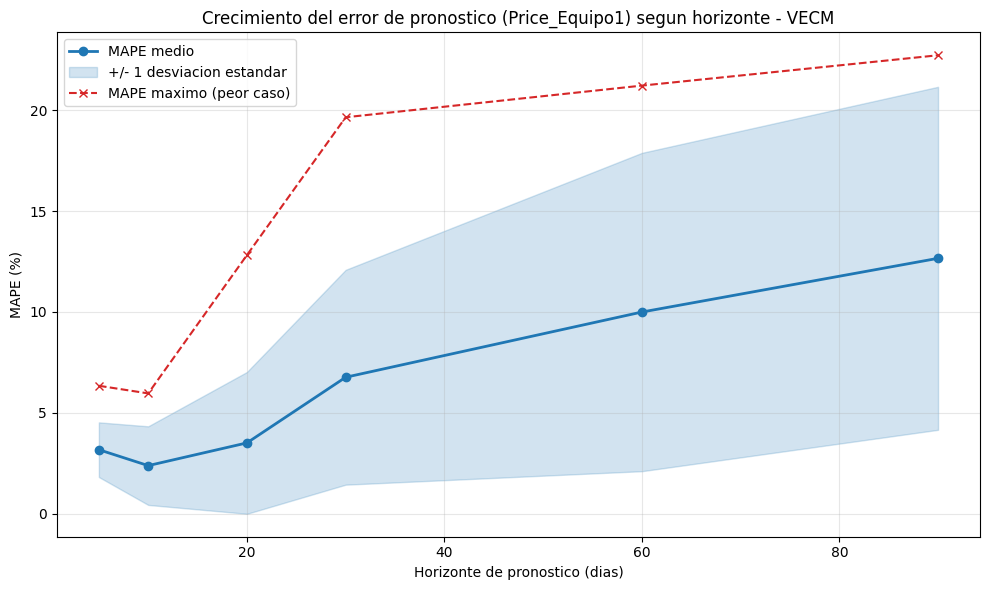

In [19]:
def walk_forward_por_horizonte(df, columnas, coint_rank, horizonte, ventana_minima=1500, paso=250):
    resultados = []
    for corte in range(ventana_minima, len(df) - horizonte, paso):
        train = df.iloc[:corte].reset_index(drop=True)
        test = df.iloc[corte:corte + horizonte].reset_index(drop=True)
        try:
            resultado, _ = entrenar_vecm(train, columnas, coint_rank, maxlags=10)
            forecast, _, _ = resultado.predict(steps=horizonte, alpha=0.05)
            real = test[columnas].values
            mape_e1 = np.abs((real[-1, 2] - forecast[-1, 2]) / real[-1, 2]) * 100
            resultados.append(mape_e1)
        except Exception:
            pass
    return np.mean(resultados), np.std(resultados), np.max(resultados)

horizontes = [5, 10, 20, 30, 60, 90]
resultados_por_horizonte = []
for h in horizontes:
    media, std, maximo = walk_forward_por_horizonte(historico_equipos, columnas, COINT_RANK, h)
    resultados_por_horizonte.append({'horizonte': h, 'mape_medio': media, 'mape_std': std, 'mape_max': maximo})

df_resultados = pd.DataFrame(resultados_por_horizonte)
print(df_resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_resultados['horizonte'], df_resultados['mape_medio'], marker='o', linewidth=2,
        color='#1f77b4', label='MAPE medio')
ax.fill_between(df_resultados['horizonte'],
                 df_resultados['mape_medio'] - df_resultados['mape_std'],
                 df_resultados['mape_medio'] + df_resultados['mape_std'],
                 alpha=0.2, color='#1f77b4', label='+/- 1 desviacion estandar')
ax.plot(df_resultados['horizonte'], df_resultados['mape_max'], marker='x', linestyle='--',
        color='#d62728', label='MAPE maximo (peor caso)')
ax.set_xlabel('Horizonte de pronostico (dias)')
ax.set_ylabel('MAPE (%)')
ax.set_title('Crecimiento del error de pronostico (Price_Equipo1) segun horizonte - VECM')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Simulación Monte Carlo <a id='11-montecarlo'></a>

Se simulan 2000 trayectorias conjuntas de las 4 variables, usando bootstrap de residuos
históricos reales (preserva colas pesadas y correlación entre variables, a diferencia de
asumir una distribución normal).

--- Price_Equipo1 ---
 dia         P5        P25    mediana        P75        P95
  30 396.409621 427.519392 446.359710 466.951923 500.268948
  60 376.987429 419.771005 448.239661 476.599521 522.811188
  90 359.633667 410.221874 448.116350 484.289913 540.392095


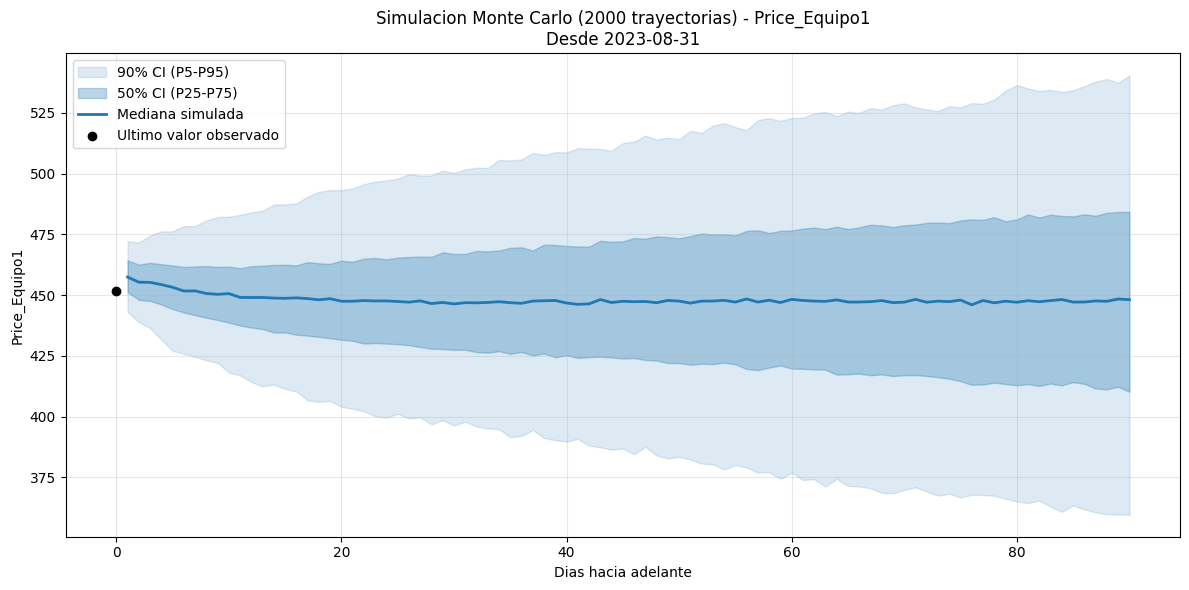

--- Price_Equipo2 ---
 dia         P5        P25    mediana        P75         P95
  30 814.903937 875.326643 916.493377 959.407395 1021.416783
  60 774.236241 857.684546 921.361732 975.217059 1055.215852
  90 742.900770 845.040714 920.127873 991.315718 1090.145965


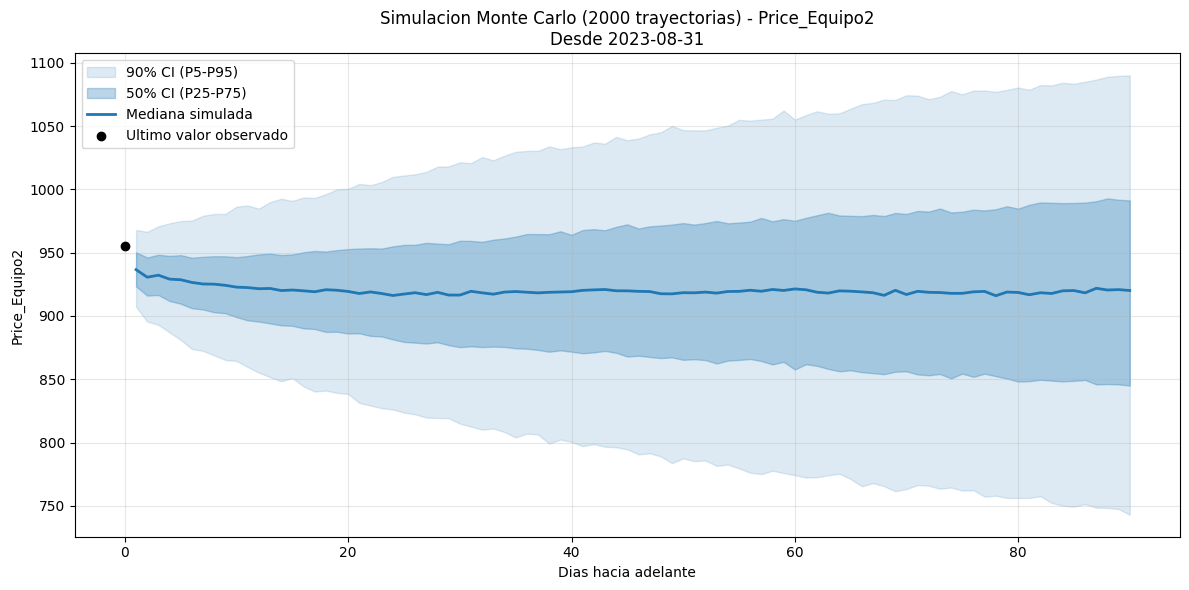

In [21]:
RANDOM_STATE = 42
def simular_montecarlo(resultado_vecm, df, columnas, horizonte, n_simulaciones, semilla=RANDOM_STATE):
    k_ar = resultado_vecm.k_ar
    var_rep = resultado_vecm.var_rep
    residuos_historicos = resultado_vecm.resid
    n_vars = len(columnas)
    valores_iniciales = df[columnas].values[-k_ar:]

    np.random.seed(semilla)
    simulaciones = np.zeros((n_simulaciones, horizonte, n_vars))

    for sim in range(n_simulaciones):
        historia = list(valores_iniciales)
        for t in range(horizonte):
            pred = np.zeros(n_vars)
            for lag in range(k_ar):
                pred += var_rep[lag] @ historia[-(lag + 1)]
            shock = residuos_historicos[np.random.randint(0, len(residuos_historicos))]
            nuevo_valor = pred + shock
            historia.append(nuevo_valor)
            simulaciones[sim, t, :] = nuevo_valor

    return simulaciones

def resumen_percentiles(simulaciones, columnas, variable, dias_hito):
    idx = columnas.index(variable)
    filas = []
    for dia in dias_hito:
        valores = simulaciones[:, dia - 1, idx]
        p5, p25, p50, p75, p95 = np.percentile(valores, [5, 25, 50, 75, 95])
        filas.append({'dia': dia, 'P5': p5, 'P25': p25, 'mediana': p50, 'P75': p75, 'P95': p95})
    return pd.DataFrame(filas)

def graficar_fanchart(simulaciones, df, columnas, variable):
    idx = columnas.index(variable)
    horizonte = simulaciones.shape[1]
    bandas = np.percentile(simulaciones[:, :, idx], [5, 25, 50, 75, 95], axis=0)

    fig, ax = plt.subplots(figsize=(12, 6))
    dias_futuros = np.arange(1, horizonte + 1)
    ultimo_valor = df[variable].iloc[-1]
    ultima_fecha = df['Date'].iloc[-1]

    ax.fill_between(dias_futuros, bandas[0], bandas[4], alpha=0.15, color='#1f77b4', label='90% CI (P5-P95)')
    ax.fill_between(dias_futuros, bandas[1], bandas[3], alpha=0.3, color='#1f77b4', label='50% CI (P25-P75)')
    ax.plot(dias_futuros, bandas[2], color='#1f77b4', linewidth=2, label='Mediana simulada')
    ax.scatter([0], [ultimo_valor], color='black', zorder=5, label='Ultimo valor observado')
    ax.set_xlabel('Dias hacia adelante')
    ax.set_ylabel(variable)
    ax.set_title(f'Simulacion Monte Carlo ({simulaciones.shape[0]} trayectorias) - {variable}\nDesde {ultima_fecha.date()}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

HORIZONTE = 90
N_SIMULACIONES = 2000

resultado_vecm_final, _ = entrenar_vecm(historico_equipos, columnas, COINT_RANK)
simulaciones = simular_montecarlo(resultado_vecm_final, historico_equipos, columnas, HORIZONTE, N_SIMULACIONES)

for variable in ['Price_Equipo1', 'Price_Equipo2']:
    print(f"--- {variable} ---")
    print(resumen_percentiles(simulaciones, columnas, variable, [30, 60, 90]).to_string(index=False))
    graficar_fanchart(simulaciones, historico_equipos, columnas, variable)

## 14. Conclusiones de negocio y limitaciones <a id='14-conclusiones'></a>

### Hallazgos principales

- `Price_Equipo1` y `Price_Equipo2` son canastas ponderadas de insumos (X, Y, Z), no
  precios independientes: `Equipo1 ≈ 0.20·X + 0.80·Y`, `Equipo2 ≈ 0.33·X + 0.33·Y + 0.33·Z`.
- Y y Z son débilmente exógenas (conducen el sistema); Equipo1 y Equipo2 se ajustan
  hacia ellas. X aporta poco poder explicativo, tanto en corto como en largo plazo.
- El error de pronóstico crece de ~2-3% (5-10 días) a ~12-13% (90 días) — recalibrar el
  modelo con frecuencia es más efectivo que confiar en un pronóstico estático lejano.
- El quiebre real detectado (2020-2022) es de **varianza**, no de nivel ni de la relación
  estructural — la fórmula de composición se mantiene estable en todo el período.

### Limitaciones

- El VECM no incorpora mano de obra ni costos logísticos, mencionados como drivers
  relevantes en fuentes técnicas del sector.
- Las variables exógenas (TRM, DXY) no mostraron relación de largo plazo con los insumos;
  no se descarta que aporten en otros contextos (ej. economías con mayor volatilidad
  cambiaria).

### Próximos pasos
- Evaluar variables de mano de obra/logística si hay datos disponibles.
